In [156]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *
import emcee

In [157]:
%matplotlib widget
plt.close('all')

In [158]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

In [159]:
elettrometro_dir = os.path.join(base_img_folder, folder_selector.value, 'data/points_keithley.txt')
keithley_currents, keithley_timestamps, keithley_ranges = load_keithley_data(elettrometro_dir)

keithley_currents = np.array(keithley_currents)
keithley_timestamps = np.array(keithley_timestamps)
keithley_trel = keithley_timestamps - keithley_timestamps[0]

In [160]:
auto_range_indices = np.array([i for i, r in enumerate(keithley_ranges) if r == -1])
plus2_inds = auto_range_indices - 1
plus1_inds = auto_range_indices - 2

elettrometro_masks = {
    "auto" : auto_range_indices,
    "+2" : plus2_inds,
    "+1" : plus1_inds
}



In [161]:
# impostiamo a 0 i valori non sensati (NaN e molto grandi)
keithley_currents = np.nan_to_num(keithley_currents, nan=0.0, posinf=0.0, neginf=0.0)
keithley_trel = np.nan_to_num(keithley_trel, nan=0.0, posinf=0.0, neginf=0.0)

max_current = 1e-1  # Soglia massima di corrente (in A)
keithley_currents[np.abs(keithley_currents) > max_current] = 0.0

In [162]:
# compute the median and the standard deviation of the current values between the 3 ranges

range_auto = keithley_currents[elettrometro_masks["auto"]]
range1 = keithley_currents[elettrometro_masks["+1"]]
range2 = keithley_currents[elettrometro_masks["+2"]]

# build an array where each element is (value auto, value +1, value +2) for each index in the auto range
terne = np.array([range1, range2, range_auto])

# compute the median and std_dev at each index
median = np.median(terne, axis=0)
std_dev = np.std(terne, axis=0)     # rivalutare. La std_dev di 3 valori ha poco senso, un'alternativa potrebbe essere dare un range con le differenze tra mediana e valori estremi (min e max)


In [163]:
def current_model(t, tc, A, p):
    """
    Modello della corrente in funzione di t (non ancora definito, può essere un tempo o altro).

    Prima di tc, il modello restituisce corrente=0.
    Dopo tc, il modello restituisce corrente=A*(t-tc)^p.

    Args:
        t (float or np.ndarray): Tempo o variabile indipendente.
        tc (float): Tempo di cutoff.
        A (float): Ampiezza della corrente.
        p (float): Esponente della potenza.
    
    Returns:
        float or np.ndarray: Valore della corrente calcolato secondo il modello.
    """

    # Convertiamo t in un array numpy per gestire sia scalari che array
    t = np.asarray(t)

    # Creiamo un array di zeri con la stessa forma di t
    current = np.zeros_like(t)

    # Applichiamo il modello solo per i valori di t maggiori di tc
    mask = t > tc
    current[mask] = A * (t[mask] - tc) ** p

    return current

FloatSlider(value=0.0, description='tc', max=4187.232023, step=41.87232022999999)

FloatSlider(value=1e-06, description='A', max=0.001, min=1e-09, step=9.999990000000002e-06)

FloatSlider(value=1.0, description='p', max=5.0, min=0.1, step=0.049)

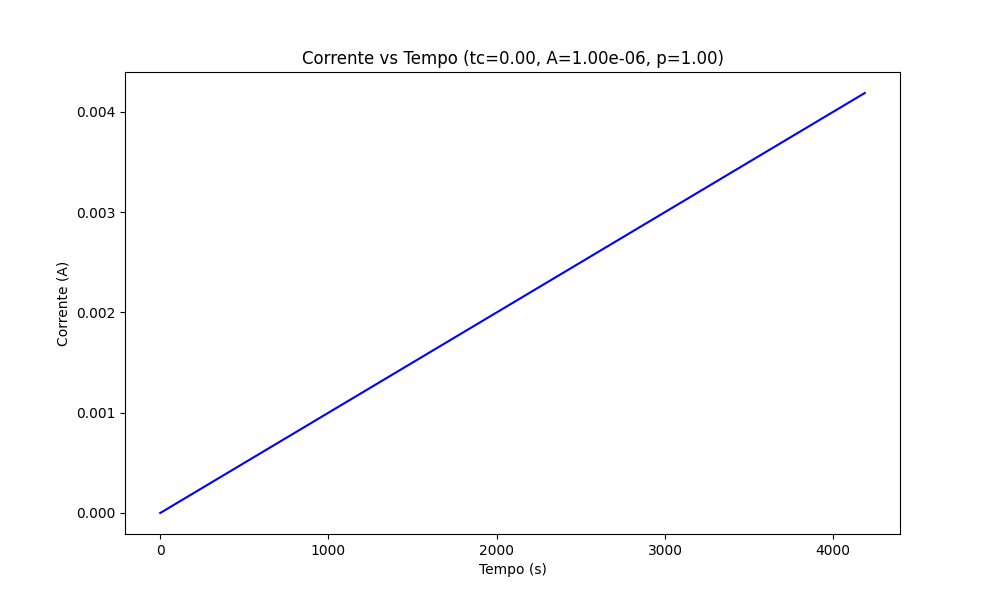

In [164]:
with plt.ioff():
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)

    ax.set_title("Corrente vs Tempo")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Corrente (A)")

    line = ax.plot([], [], label="Dati Keithley", color='blue')[0]

    canvas = fig.canvas

xs = np.linspace(0, keithley_trel[-1], 1000)

param_names = ["tc", "A", "p"]
param_defaults = [0.0, 1e-6, 1.0]  # Valori iniziali per tc, A e p
param_ranges = [(0, np.max(keithley_trel)), (1e-9, 1e-3), (0.1, 5)]  # Intervalli per tc, A e p

param_selectors = [widgets.FloatSlider(value=default, min=range_[0], max=range_[1], step=(range_[1]-range_[0])/100, description=name) for name, default, range_ in zip(param_names, param_defaults, param_ranges)]

def update_plot(change):
    # Otteniamo i valori dei parametri dai selettori
    tc = param_selectors[0].value
    A = param_selectors[1].value
    p = param_selectors[2].value

    # Calcoliamo la corrente secondo il modello
    model_currents = current_model(xs, tc, A, p)

    # Aggiorniamo la linea del modello nel grafico
    line.set_data(xs, model_currents)
    #line.set_ydata(model_currents)
    
    # Aggiorniamo il titolo del grafico con i valori correnti dei parametri
    ax.set_title(f"Corrente vs Tempo (tc={tc:.2f}, A={A:.2e}, p={p:.2f})")

    ax.relim()  # Ricalcoliamo i limiti dell'asse
    ax.autoscale_view()  # Aggiorniamo la visualizzazione dell'asse
    
    # Ridisegniamo il canvas
    canvas.draw_idle()

update_plot(None)  # Inizializza il grafico con i valori di default

[selector.observe(update_plot, names='value') for selector in param_selectors]
[display(selector) for selector in param_selectors]
display(canvas)



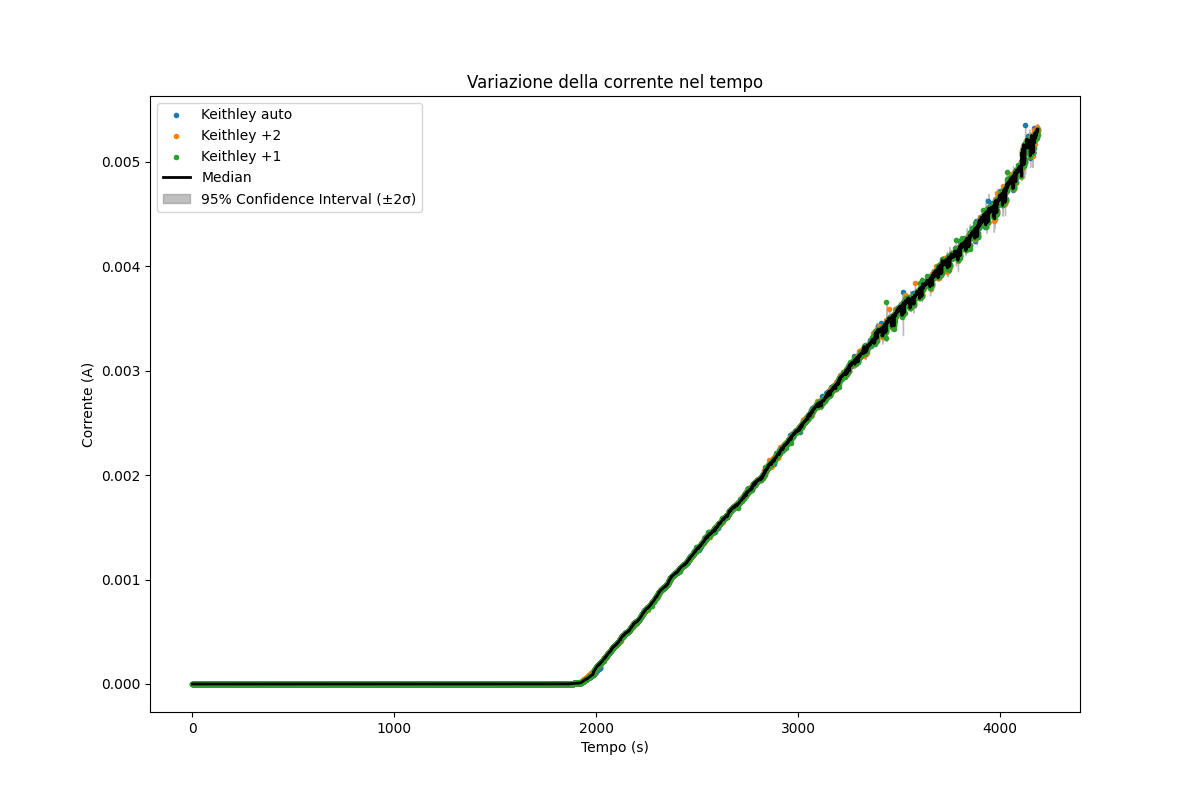

In [165]:
plt.figure(figsize=(12, 8))

#plt.plot(keithley_trel, keithley_currents, label='Keithley', color='red', marker='o', markersize=3, linestyle='none')
for name, mask in elettrometro_masks.items():
    plt.plot(keithley_trel[mask], keithley_currents[mask], label=f'Keithley {name}', marker='o', markersize=3, linestyle='none')

#plt.errorbar(keithley_trel[elettrometro_masks["auto"]], median, yerr=std_dev, fmt='o', color='black', label='Median ± Std Dev')
plt.plot(keithley_trel[elettrometro_masks["auto"]], median, color='black', label='Median', linewidth=2)
plt.fill_between(keithley_trel[elettrometro_masks["auto"]], median - 2 * std_dev, median + 2 * std_dev, color='gray', alpha=0.5, label='95% Confidence Interval (±2σ)')

plt.xlabel('Tempo (s)')
plt.ylabel('Corrente (A)')
plt.title('Variazione della corrente nel tempo')
plt.legend()
plt.show()